# Reading tables - Live Coding Session

**Session length:** 2 hours 30 minutes

### Yesterday, we processed images on FIJI, did some measurements and saved those into tables as CSV files. 
### Today, we will use Python to read, process and visualise statistics from those tables.

## Learning goals

By the end of this session, you should be able to:

- Read CSV data into pandas dataframes
- Find and evaluate values from specific columns
- Select items which fulfil some measurement criteria
- Make scatter and line plots from measurements
- Save plots as images
- Create pivot tables to summarise data
- Save pandas dataframes to CSV files
- Process multiple tables and obtain useful information

Import the required packages for this activity

In [1]:
import numpy as np
import pandas as pd
from PIL import Image
from matplotlib import pyplot as plt
from pathlib import Path

In [2]:
# Define the directory where the csv files from FIJI are located
data_dir = Path(r"C:\Users\Dell\Documents\Course_Intro_ImageAnalysis\Introduction_BioImaging_Course_2026\data")

Now we will use Pandas to read the csv files we generated previously on FIJI. We will start with a single example.

In [3]:
# define the csv name and read it with pd.read_csv()
csv_name = "Results_rounding_assay0005.csv"

df = pd.read_csv(Path(data_dir / csv_name))

In [4]:
# print the df
df

,,Area,XM,YM,Circ.,AR,Round,Solidity
0,1,191,356.703,9.895,0.357,5.971,0.167,0.729
1,2,99,412.573,19.145,0.402,4.791,0.209,0.750
2,3,85,366.359,22.891,0.903,1.771,0.565,0.934
3,4,152,244.080,38.431,0.483,4.089,0.245,0.788
4,5,133,216.666,47.481,0.562,3.530,0.283,0.792
5,6,62,495.172,52.043,0.967,1.366,0.732,0.919
6,7,139,160.666,88.865,0.386,5.619,0.178,0.737
7,8,163,150.521,96.547,0.367,4.421,0.226,0.652
8,9,41,345.662,89.999,0.696,2.619,0.382,0.820
9,10,128,440.110,115.244,0.485,4.347,0.230,0.783


Let's retrieve a sub-dataframe with the areas of all the segmented objects. This involves calling the "Area" column of our dataframe via `df["Area"]`

In [5]:
# get the areas from df
df["Area"]

0     191
1      99
2      85
3     152
4     133
5      62
6     139
7     163
8      41
9     128
10    109
11    131
12    131
13    181
14    213
15    131
16    149
17    227
18    142
19    110
20    100
21     74
22    145
23    139
24    163
25    195
26     45
27    105
28    155
29    151
30    173
31    128
32    186
33    142
34    158
35     77
36    174
37    158
38    210
39     49
40     74
41     58
42    110
43     99
44    116
Name: Area, dtype: int64

In [6]:
# get the areas as a list with tolist(). The [:5] causes just the first 5 values to be printed
df["Area"].tolist()[:5]

[191, 99, 85, 152, 133]

You can also retrieve a desired value for a specific row. Let us display the area of the 10th cell.

In [7]:
# print the area of the 10th row using df.loc[index,attribute]
df.loc[0,"Area"]

np.int64(191)

We can obtain details such as the number of objects, as well as statistics about the areas, such as the mean, standard deviation and median.

In [8]:
# get the number of rows in the df
len(df)

45

In [9]:
# find the mean of the areas and print it
mean_area = df["Area"].mean()
print(f"Mean area is {mean_area:.2f}")

Mean area is 131.13


## Exercise 1

Like with the mean, calculate and print (with f-strings) the standard deviation and the median area. The relevant commands are `.std()` and `.median()`

In [10]:
# Your code here
std_area = df["Area"].std()
print(f"Std area is {std_area:.2f}")

median_area = df["Area"].median()
print(f"Median area is {median_area:.2f}")

Std area is 46.21
Median area is 133.00


We can learn about the distribution of area values by plotting a histogram. This will show us the frequencies at which ranges of areas occur in our data.

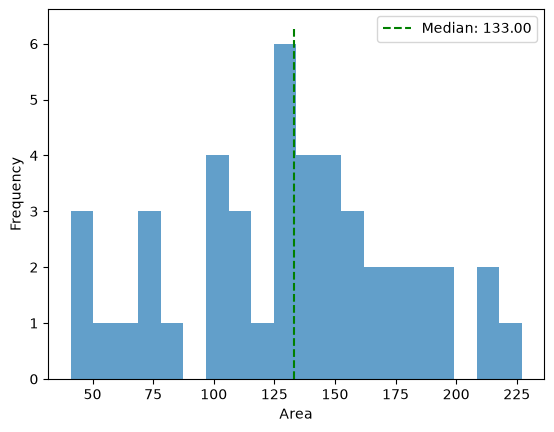

In [11]:
# Plot a histogram with a vertical line at the median, and add appropriate labels and title.
plt.hist(df["Area"], bins=20, alpha=0.7)
plt.vlines(median_area, ymin=0, ymax=plt.gca().get_ylim()[1], 
           color='green', linestyle='dashed', label=f'Median: {median_area:.2f}')
plt.xlabel("Area")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## Exercise 2

Make a plot of the histogram, with narrower bins, and with lines depicting the mean area +/- the standard deviation. You may use the above code.

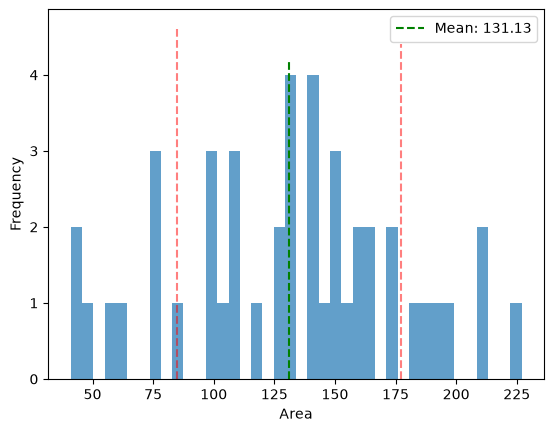

In [12]:
# Your code here
# Plot a histogram with a vertical line at the median, and add appropriate labels and title.
plt.hist(df["Area"], bins=40, alpha=0.7)

plt.vlines(mean_area, ymin=0, ymax=plt.gca().get_ylim()[1], 
           color='green', linestyle='dashed', label=f'Mean: {mean_area:.2f}')

plt.vlines(mean_area + std_area, ymin=0, ymax=plt.gca().get_ylim()[1], 
           color='red', linestyle='dashed', alpha=0.5)

plt.vlines(mean_area - std_area, ymin=0, ymax=plt.gca().get_ylim()[1], 
           color='red', linestyle='dashed', alpha=0.5)

plt.xlabel("Area")
plt.ylabel("Frequency")
plt.legend()
# if you want to save the plot, then do that before plt.show()
plot_savename = "sample.png"
plt.savefig(plot_savename)
plt.show()

You can save a figure as an image for use in presentations or papers. See the end of the above cell.

We can also make scatter plots if we are interested in visually seeing whether some pair of parameter may be correlated. Try it out!

Text(0, 0.5, 'Round')

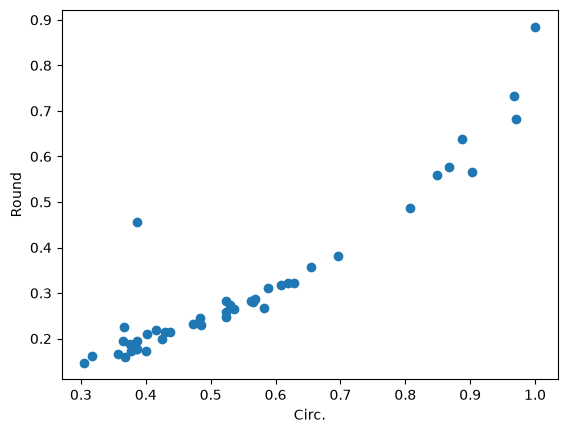

In [13]:
# TO DO: enter your parameters of interest as two strings. These must match the desired column names in the dataframe. Enter these in the following 2 lines
param_1 = "Circ."
param_2 = "Round"

plt.scatter(df[param_1], df[param_2])
plt.xlabel(param_1)
plt.ylabel(param_2)

## Exercise 3

On the same plot, add a point representing the means of your two chosen parameters. Use a different color and marker style to distinguish this point from the other data points.

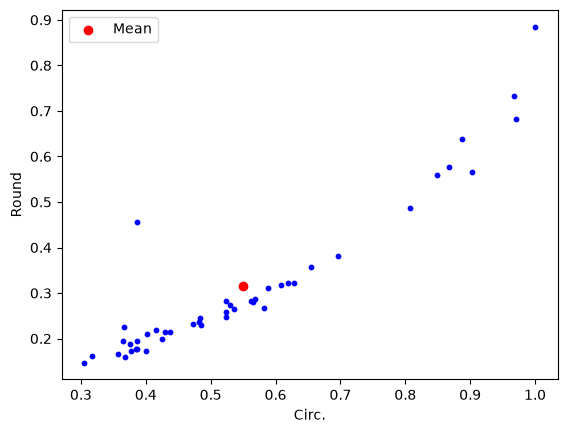

In [14]:
# TO DO: 
# Include a legend to indicate what this point represents. You can use the label parameter in plt.scatter() to specify the legend entry for this point. 
# Some marker styles you can use are 'o', 's', '^', 'D', '*', etc. You can also specify the size of the marker using the s parameter in plt.scatter().
# You can use plt.scatter() again for this, but make sure to specify the mean values of your chosen parameters as the x and y coordinates of this point.
# Enter your code above plt.xlabel()

# Your code here
param_1 = "Circ."
param_2 = "Round"

plt.scatter(df[param_1], df[param_2], s=10, color='blue') # s means size of the plotted point
# now find the means and have them plotted as a red point
plt.scatter(df[param_1].mean(), df[param_2].mean(), color='red', label="Mean")
plt.xlabel(param_1)
plt.ylabel(param_2)
plt.legend()

Now that we have a dataframe open here, we can also add columns if we like.

In [15]:
# Displaying 5 random rows from the table
df.sample(n=5)

,,Area,XM,YM,Circ.,AR,Round,Solidity
14,15,213,434.257,138.752,0.365,5.119,0.195,0.734
26,27,45,279.491,349.083,0.970,1.467,0.682,0.928
29,30,151,397.685,389.740,0.530,3.651,0.274,0.778
7,8,163,150.521,96.547,0.367,4.421,0.226,0.652
27,28,105,57.098,373.698,0.305,6.815,0.147,0.682


In [16]:
# Add a new column called Time
df["Time"] = 5
df

,,Area,XM,YM,Circ.,AR,Round,Solidity,Time
0,1,191,356.703,9.895,0.357,5.971,0.167,0.729,5
1,2,99,412.573,19.145,0.402,4.791,0.209,0.750,5
2,3,85,366.359,22.891,0.903,1.771,0.565,0.934,5
3,4,152,244.080,38.431,0.483,4.089,0.245,0.788,5
4,5,133,216.666,47.481,0.562,3.530,0.283,0.792,5
5,6,62,495.172,52.043,0.967,1.366,0.732,0.919,5
6,7,139,160.666,88.865,0.386,5.619,0.178,0.737,5
7,8,163,150.521,96.547,0.367,4.421,0.226,0.652,5
8,9,41,345.662,89.999,0.696,2.619,0.382,0.820,5
9,10,128,440.110,115.244,0.485,4.347,0.230,0.783,5


This overwrites our df variable, but the csv is unchanged. We can save this updated df as a new csv file (or overwrite our original one)

In [17]:
# save the updated dataframe as a new csv file using df.to_csv()
df.to_csv("new_0005.csv")

Notice that we applied the same value to every single row of the dataframe. We can also assign values to individual rows.

In [18]:
# assign a time value to some row using loc. We are doing this for rows 0 to 5
df.loc[0:5, "Time"] = 1
df

,,Area,XM,YM,Circ.,AR,Round,Solidity,Time
0,1,191,356.703,9.895,0.357,5.971,0.167,0.729,1
1,2,99,412.573,19.145,0.402,4.791,0.209,0.750,1
2,3,85,366.359,22.891,0.903,1.771,0.565,0.934,1
3,4,152,244.080,38.431,0.483,4.089,0.245,0.788,1
4,5,133,216.666,47.481,0.562,3.530,0.283,0.792,1
5,6,62,495.172,52.043,0.967,1.366,0.732,0.919,1
6,7,139,160.666,88.865,0.386,5.619,0.178,0.737,5
7,8,163,150.521,96.547,0.367,4.421,0.226,0.652,5
8,9,41,345.662,89.999,0.696,2.619,0.382,0.820,5
9,10,128,440.110,115.244,0.485,4.347,0.230,0.783,5


In [19]:
# optional code: if you would like to change the position of the "Time" column
time = df.pop("Time")
df.insert(1, "Time", time)
df.sample(n=5)

,,Time,Area,XM,YM,Circ.,AR,Round,Solidity
35,36,5,77,42.309,444.978,0.317,6.176,0.162,0.748
18,19,5,142,57.019,193.581,0.472,4.292,0.233,0.791
29,30,5,151,397.685,389.740,0.530,3.651,0.274,0.778
16,17,5,149,194.376,165.853,0.524,4.057,0.247,0.884
3,4,1,152,244.080,38.431,0.483,4.089,0.245,0.788


We can also iterate with a for loop, check each row for some condition, and then write whether or not it is true in a new column.

As an example, let us make a new column which stores whether or not an object (a row) has an area greater than 100

In [20]:
# iterate through the rows with df.iterrows() and assign a largeness boolean to each row based on an area condition
for i,item in df.iterrows():
    if item["Area"] > mean_area:
        df.at[i, "Size"] = "Large"
    else:
        df.at[i, "Size"] = "Small"

df.sample(n=5)

,,Time,Area,XM,YM,Circ.,AR,Round,Solidity,Size
40,41,5,74,184.408,480.254,0.887,1.568,0.638,0.914,Small
5,6,1,62,495.172,52.043,0.967,1.366,0.732,0.919,Small
21,22,5,74,222.945,231.421,1.000,1.130,0.885,0.931,Small
29,30,5,151,397.685,389.740,0.530,3.651,0.274,0.778,Large
36,37,5,174,158.110,451.355,0.385,5.639,0.177,0.755,Large


There is a simpler way through which we could do the same thing as above but with a single line of code

In [21]:
# delete the column called "Area condition" from the dataframe using drop(), then recreate this column with one line of code.
df["Largeness"] = df["Area"] > mean_area
df

,,Time,Area,XM,YM,Circ.,AR,Round,Solidity,Size,Largeness
0,1,1,191,356.703,9.895,0.357,5.971,0.167,0.729,Large,True
1,2,1,99,412.573,19.145,0.402,4.791,0.209,0.750,Small,False
2,3,1,85,366.359,22.891,0.903,1.771,0.565,0.934,Small,False
3,4,1,152,244.080,38.431,0.483,4.089,0.245,0.788,Large,True
4,5,1,133,216.666,47.481,0.562,3.530,0.283,0.792,Large,True
5,6,1,62,495.172,52.043,0.967,1.366,0.732,0.919,Small,False
6,7,5,139,160.666,88.865,0.386,5.619,0.178,0.737,Large,True
7,8,5,163,150.521,96.547,0.367,4.421,0.226,0.652,Large,True
8,9,5,41,345.662,89.999,0.696,2.619,0.382,0.820,Small,False
9,10,5,128,440.110,115.244,0.485,4.347,0.230,0.783,Small,False


We may also count the number of cells that fulfil the condition from our dataframe.

In [22]:
# Count the number of cells that fulfil the condition. Use the .sum() function.
df["Largeness"].sum()

np.int64(23)

In [23]:
# You can do the same thing directly, without creating a new column
(df["Area"] > mean_area).sum()

np.int64(23)

We can slice, or select, only the rows which fulfil a condition

In [24]:
# slice the df rows that have area > the mean
print(f"Mean area is {mean_area:.2f}")
df_large = df[df["Area"] > mean_area]
print(f"Number of large cells: {len(df_large)}")
df_large

Mean area is 131.13
Number of large cells: 23


,,Time,Area,XM,YM,Circ.,AR,Round,Solidity,Size,Largeness
0,1,1,191,356.703,9.895,0.357,5.971,0.167,0.729,Large,True
3,4,1,152,244.080,38.431,0.483,4.089,0.245,0.788,Large,True
4,5,1,133,216.666,47.481,0.562,3.530,0.283,0.792,Large,True
6,7,5,139,160.666,88.865,0.386,5.619,0.178,0.737,Large,True
7,8,5,163,150.521,96.547,0.367,4.421,0.226,0.652,Large,True
13,14,5,181,206.601,135.134,0.386,5.158,0.194,0.740,Large,True
14,15,5,213,434.257,138.752,0.365,5.119,0.195,0.734,Large,True
16,17,5,149,194.376,165.853,0.524,4.057,0.247,0.884,Large,True
17,18,5,227,183.229,181.149,0.386,2.191,0.456,0.644,Large,True
18,19,5,142,57.019,193.581,0.472,4.292,0.233,0.791,Large,True


In [25]:
# demonstrate how to get the respective indices using df.index()
large_indices = df.index[df["Area"] > mean_area].tolist() # tolist converts it to a list
large_indices

[0,
 3,
 4,
 6,
 7,
 13,
 14,
 16,
 17,
 18,
 22,
 23,
 24,
 25,
 28,
 29,
 30,
 32,
 33,
 34,
 36,
 37,
 38]

In [26]:
# write the preserved indices into a new df
df_large_new = df.loc[large_indices]
df_large_new.sample(n=5)

,,Time,Area,XM,YM,Circ.,AR,Round,Solidity,Size,Largeness
30,31,5,173,266.160,401.678,0.425,5.007,0.200,0.730,Large,True
6,7,5,139,160.666,88.865,0.386,5.619,0.178,0.737,Large,True
28,29,5,155,329.868,386.417,0.438,4.641,0.215,0.723,Large,True
22,23,5,145,87.436,232.543,0.482,4.241,0.236,0.797,Large,True
7,8,5,163,150.521,96.547,0.367,4.421,0.226,0.652,Large,True


## Exercise 4

Select the cells which are sufficiently circular, then find the mean area of them.

In [27]:
# Your code here
df_circular = df[df["Circ."] >= 0.6]
df_not_circular = df[df["Circ."] < 0.6]
# below you f-string uses double quotations, so inside the curly brackets you must use single quotations
print(f"Mean area of circular cells is {df_circular['Area'].mean()}")
print(f"Mean area of non-circular cells is {df_not_circular['Area'].mean()}")

Mean area of circular cells is 87.0
Mean area of non-circular cells is 149.0625


## Exercise 5

Building on this, also select cells that are not circular. Then, make a scatter plot with Circularity as the x-axis and Area as the y-axis.
Indicate the cell category (circular or not) with different marker colours, and include a legend.

Text(0, 0.5, 'Area')

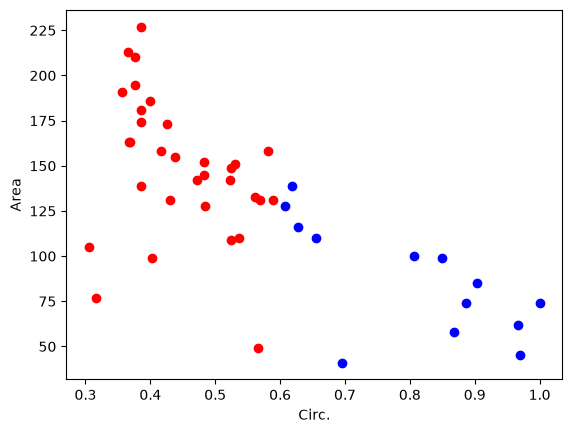

In [28]:
# Your code here
# for scatter we do plt.scatter(x_values, y_values). color etc. are optional
plt.scatter(df_circular["Circ."], df_circular["Area"], color='blue')
plt.scatter(df_not_circular["Circ."], df_not_circular["Area"], color='red')
plt.xlabel("Circ.")
plt.ylabel("Area")

Using pivot tables, we can get more statistics about certain cells.

In [29]:
print(mean_area)

131.13333333333333


In [30]:
# make a pivot table that stores the median, mean and std of large and small cells
# the pivot table is also a dataframe
df["Large"] = df["Area"] > mean_area
pd.pivot_table(
    df,
    values="Area",
    index="Large",
    aggfunc=["mean", "std"]
)

,mean,std
,Area,Area
Large,,
False,93.727273,29.737233
True,166.913043,26.257316


## Exercise 6

Create a pivot table which stores the mean area of circular and non-circular cells

In [31]:
# Your code here
# create a new column, which stores whether a row is circular or not as a boolean
df["Is_Circular"] = df["Circ."] > 0.6
pivot_6 = pd.pivot_table(df,
              values = "Area",
              index="Is_Circular",
              aggfunc=["mean", "std"])

pivot_6

,mean,std
,Area,Area
Is_Circular,,
False,149.0625,38.772236
True,87.0000,31.299627


You can also do arithmetic between columns. For example, let's create a new column that is the product of the "Circ." and "Round" columns.

In [32]:
# show the multiplication of two columns and add this as a new column
df["Area * Circ."] = df["Area"] * df["Circ."]
df.sample(n=5) # a new column has been added

,,Time,Area,XM,YM,Circ.,AR,Round,Solidity,Size,Largeness,Large,Is_Circular,Area * Circ.
27,28,5,105,57.098,373.698,0.305,6.815,0.147,0.682,Small,False,False,False,32.025
9,10,5,128,440.110,115.244,0.485,4.347,0.230,0.783,Small,False,False,False,62.080
37,38,5,158,13.807,462.558,0.416,4.568,0.219,0.751,Large,True,True,False,65.728
1,2,1,99,412.573,19.145,0.402,4.791,0.209,0.750,Small,False,False,False,39.798
31,32,5,128,141.249,399.130,0.608,3.141,0.318,0.850,Small,False,False,True,77.824


Now, let us concatenate another dataframe to this one. That is to say, combine two dataframes into one. We can do this using the `concat()` function. Notice that the argument to `concat()` is a list of the dataframes we wish to combine

In [33]:
# Read another csv file and combine it with the preexisting one
csv_name_2 = "Results_rounding_assay0006.csv"
df_2 = pd.read_csv(Path(data_dir / csv_name_2))

In [34]:
df_combined = pd.concat([df, df_2], ignore_index=True)
# if you want you may save the df using df_combined.to_csv("some_name.csv")
df_combined

,,Time,Area,XM,YM,Circ.,AR,Round,Solidity,Size,Largeness,Large,Is_Circular,Area * Circ.
0,1,1.0,191,356.703,9.895,0.357,5.971,0.167,0.729,Large,True,True,False,68.187
1,2,1.0,99,412.573,19.145,0.402,4.791,0.209,0.750,Small,False,False,False,39.798
2,3,1.0,85,366.359,22.891,0.903,1.771,0.565,0.934,Small,False,False,True,76.755
3,4,1.0,152,244.080,38.431,0.483,4.089,0.245,0.788,Large,True,True,False,73.416
4,5,1.0,133,216.666,47.481,0.562,3.530,0.283,0.792,Large,True,True,False,74.746
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,37,NaN,151,11.107,461.910,0.456,4.134,0.242,0.749,NaN,NaN,NaN,NaN,NaN
82,38,NaN,205,130.653,457.657,0.378,5.724,0.175,0.728,NaN,NaN,NaN,NaN,NaN
83,39,NaN,61,129.256,495.495,0.877,1.732,0.577,0.924,NaN,NaN,NaN,NaN,NaN
84,40,NaN,114,215.886,499.891,0.608,3.178,0.315,0.838,NaN,NaN,NaN,NaN,NaN


Notice that there are `NaN` values in the new dataframe for the columns Time, Area condition and C*R. This is because we did not create that column for `df_2`. So, the time column values corresponding to its rows were set to "Not a Number" 

## Processing multiple CSV files and getting information based on the time point

We will apply the principles we have learned today to visualise how some parameters varied with time points.

In [35]:
# Delete the dataframes we no longer need to free up memory
del df, df_2, df_large, df_circular, df_not_circular

We have 64 csv files that we generated from the 64 images in FIJI. Let us iterate through all of them and find the number of cells detected in each image.

In [36]:
# Define the directory where the csv files from FIJI are located
data_dir = Path(r"C:\Users\Dell\Documents\Course_Intro_ImageAnalysis\Introduction_BioImaging_Course_2026\data")

In [37]:
# we will put the dataframes read from all csv files into a list, and then combine them at the end.

# get the number of csv files which follow our naming format: name begins with Results and ends with csv
n_csv = len(list(data_dir.glob("Results*.csv")))
print(n_csv)

# create empty lists for all the dfs and the cell counts
df_combined = []
list_num_cells = []

# iterate through the directory, read each csv file and find the cell count in each.
for i in range(n_csv):
    filename = f"Results_rounding_assay{str(i).zfill(4)}.csv"
    df_current = pd.read_csv(Path(data_dir / filename))
    df_current["Time"] = i # add a time column to the current (i_th) csv file's dataframe
    df_combined.append(df_current) # append this df to the list of all dfs

    # find the number of cells in the table
    num_cells = len(df_current)
    # append that to the list which will track number of cells by time point
    list_num_cells.append(num_cells)

64


In [38]:
# Combine all the dfs in the list into a single dataframe using concat. Then, save this to a new csv file.
df_combined = pd.concat(df_combined)
df_combined.to_csv("combined_all.csv")
df_combined.sample(n=5)

,,Area,XM,YM,Circ.,AR,Round,Solidity,Time
34,35,65,31.822,465.569,0.691,2.284,0.438,0.855,30
11,12,204,220.025,144.657,0.418,5.225,0.191,0.777,2
30,31,77,306.672,401.542,0.957,1.153,0.868,0.917,49
0,1,93,176.414,49.146,1.000,1.136,0.880,0.944,43
28,29,75,10.520,378.059,0.967,1.009,0.991,0.898,58


Let's plot the cell count over time. Use the `plt.plot()` function to plot the x and y values. Make sure to label your axes and include a title.

Text(0, 0.5, 'Number of cells')

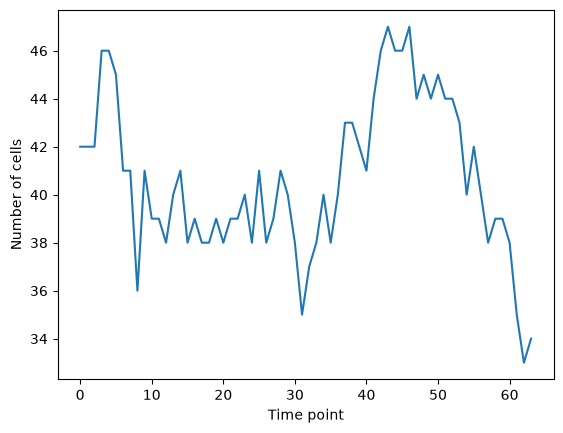

In [39]:
# Plot cell count vs time point
plt.plot(range(n_csv), list_num_cells)
plt.xlabel("Time point")
plt.ylabel("Number of cells")

## Exercise 7

From the CSVs, try to find the number of cells that are round at each time point. We'll consider a cell round if its circularity (Circ.) is greater than 0.75. Then, plot how this number varies with time.

Hint: Select/slice the rows corresponding to each time point.

In [40]:
# Your code here

# this time, we will try to find a solution by looking at our combined dataframe for all the CSVs

# get the number of csv files which follow our naming format: name begins with Results and ends with csv
n_csv = len(list(data_dir.glob("Results*.csv")))
print(n_csv)

# create an empty list for the cell count
list_num_circular = []

# iterate through the directory, read each csv file and find the cell count in each.
for i in range(n_csv):
    # select only the rows which have time value of i
    df_current = df_combined[df_combined["Time"] == i]

    # find the number of circular cells in the current df using .sum()
    num_circular = (df_current["Circ."] > 0.75).sum()
    # append that to the list which will track number of cells by time point
    list_num_circular.append(num_circular)

64


Text(0, 0.5, 'Number of circular cells')

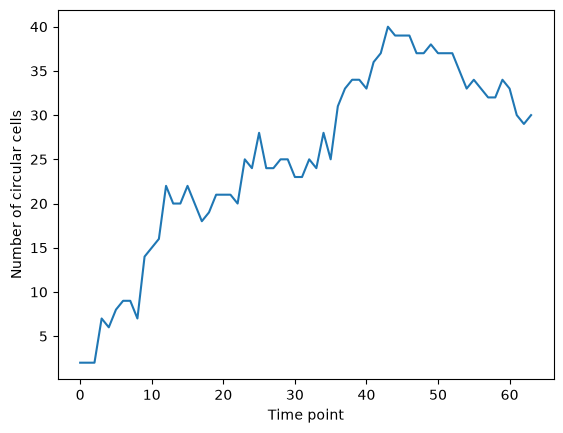

In [41]:
# Plot Circular cell count vs time point
plt.plot(range(n_csv), list_num_circular)
plt.xlabel("Time point")
plt.ylabel("Number of circular cells")